In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read the datafile

In [ ]:
df = pd.read_parquet("../data/raw/yellow_tripdata_2026-01.parquet")

In [3]:
print(df.shape)
print(df.head())
print(df.info())
print(df.columns)

(3724889, 20)
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2026-01-01 00:54:04   2026-01-01 00:59:37              1.0   
1         1  2026-01-01 00:34:04   2026-01-01 00:39:47              0.0   
2         1  2026-01-01 00:57:06   2026-01-01 01:05:59              0.0   
3         2  2026-01-01 00:15:22   2026-01-01 00:58:10              4.0   
4         2  2026-01-01 00:27:13   2026-01-01 00:40:43              0.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           0.97         1.0                  N           239           238   
1           0.90         1.0                  N           163           162   
2           1.40         1.0                  N            43           237   
3           5.58         1.0                  N           142           209   
4           2.16         1.0                  N            88           144   

   payment_type  fare_amount  extra  mta_tax  tip_amount  to

In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [5]:
na = pd.DataFrame(df.isna().sum()).reset_index(drop = False)
na.columns = ["Column", "nacount"]
na

,Column,nacount
0,VendorID,0
1,tpep_pickup_datetime,0
2,tpep_dropoff_datetime,0
3,passenger_count,1088058
4,trip_distance,0
5,RatecodeID,1088058
6,store_and_fwd_flag,1088058
7,PULocationID,0
8,DOLocationID,0
9,payment_type,0


In [6]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
#filter only january records

df =df[(df['tpep_pickup_datetime'] >= '2026-01-01') & (df['tpep_pickup_datetime'] < '2026-02-01')]

In [7]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.floor('h')


## Aggregating the data to the required columns

In [8]:
hourly_df = (
    df.groupby(['pickup_hour', 'PULocationID'])
    .agg(
        number_pickups = ("VendorID", "count")
    )
    .reset_index()
)

hourly_df.head()

,pickup_hour,PULocationID,number_pickups
0,2026-01-01,3,2
1,2026-01-01,4,78
2,2026-01-01,7,39
3,2026-01-01,9,3
4,2026-01-01,10,7


## Analysis of the aggregated data

In [9]:
print(hourly_df.head(3))
print(hourly_df.tail(3))
print(hourly_df.shape)

  pickup_hour  PULocationID  number_pickups
0  2026-01-01             3               2
1  2026-01-01             4              78
2  2026-01-01             7              39
               pickup_hour  PULocationID  number_pickups
123595 2026-01-31 23:00:00           262              59
123596 2026-01-31 23:00:00           263             175
123597 2026-01-31 23:00:00           264               5
(123598, 3)


In [10]:
print(hourly_df['PULocationID'].nunique())
print(hourly_df['pickup_hour'].nunique())


262
744


In [11]:
# what does 1 row tell us
df_loc_161 = hourly_df[hourly_df['PULocationID'] == 161].sort_values("pickup_hour")
df_loc_161['hour'] = df_loc_161['pickup_hour'].dt.hour
df_loc_161['day_of_week'] = df_loc_161['pickup_hour'].dt.dayofweek
df_loc_161.head(24)

,pickup_hour,PULocationID,number_pickups,hour,day_of_week
116,2026-01-01 00:00:00,161,261,0,3
331,2026-01-01 01:00:00,161,255,1,3
543,2026-01-01 02:00:00,161,162,2,3
750,2026-01-01 03:00:00,161,60,3,3
942,2026-01-01 04:00:00,161,17,4,3
1123,2026-01-01 05:00:00,161,19,5,3
1314,2026-01-01 06:00:00,161,23,6,3
1503,2026-01-01 07:00:00,161,22,7,3
1684,2026-01-01 08:00:00,161,28,8,3
1855,2026-01-01 09:00:00,161,65,9,3


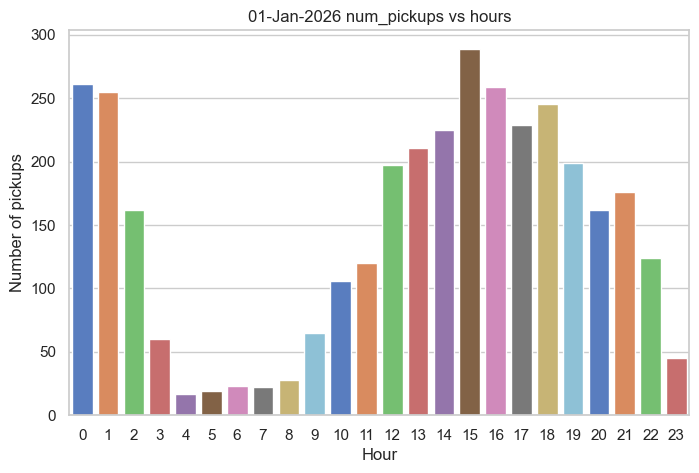

In [12]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data = df_loc_161[:24], x = "hour", y = "number_pickups", errorbar = None, palette="muted", hue = "hour", legend = False)
plt.title("01-Jan-2026 num_pickups vs hours")
plt.xlabel("Hour")
plt.ylabel("Number of pickups")
plt.show()

15th hour is the peak hour it seems and obv not many people would take a cab at 4 unless yeah partying etc.

In [13]:
agg_days = (
    df_loc_161
    .groupby(
    ["day_of_week"]
    )
    .agg(
       total_pickups =  ("number_pickups", "sum")
    )
    .reset_index()
        )
day_dict =  {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}
agg_days['day'] = agg_days['day_of_week'].apply(lambda x: day_dict[x])
agg_days.head(2)



,day_of_week,total_pickups,day
0,0,15689,Monday
1,1,23725,Tuesday


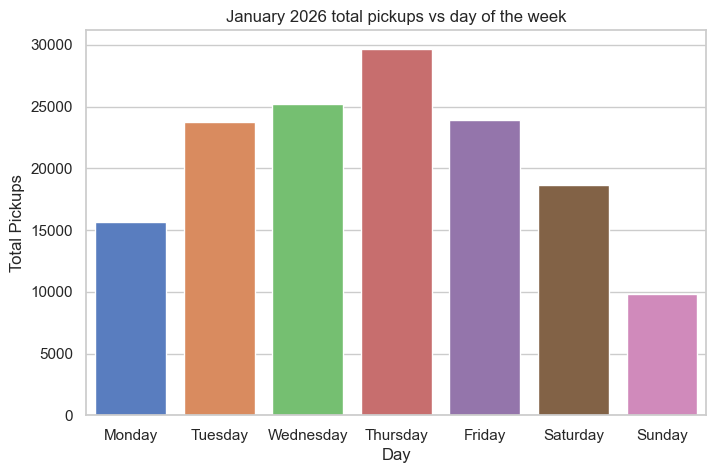

In [14]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(data = agg_days, x = "day", y = "total_pickups", errorbar = None, palette="muted", hue = "day", legend = False)
plt.title("January 2026 total pickups vs day of the week")
plt.xlabel("Day")
plt.ylabel("Total Pickups")
plt.show()

More traffic on middle week days wed, thurs and fridays. less on saturday sunday and mondays. monday is surprising not a weekend.
we need info from both these days and hours

In [15]:
hourly_df['hour'] = hourly_df['pickup_hour'].dt.hour
hourly_df['day_of_week'] = hourly_df['pickup_hour'].dt.dayofweek

hourly_df.head(3)

,pickup_hour,PULocationID,number_pickups,hour,day_of_week
0,2026-01-01,3,2,0,3
1,2026-01-01,4,78,0,3
2,2026-01-01,7,39,0,3


## Storing previous hour data to forcast or predict the data about the current hour

In [16]:
hourly_df = hourly_df.sort_values(
    ["PULocationID", "pickup_hour"]
)

#current hour has previous hours pickups by exact date and time-frame obv
hourly_df['previous_hour'] = hourly_df.groupby(['PULocationID'])['number_pickups'].shift(1)

In [18]:
hourly_df.head(10)

,pickup_hour,PULocationID,number_pickups,hour,day_of_week,previous_hour
422,2026-01-01 02:00:00,1,1,2,3,NaN
835,2026-01-01 04:00:00,1,3,4,3,1.0
1017,2026-01-01 05:00:00,1,5,5,3,3.0
1196,2026-01-01 06:00:00,1,2,6,3,5.0
1391,2026-01-01 07:00:00,1,2,7,3,2.0
1582,2026-01-01 08:00:00,1,1,8,3,2.0
1753,2026-01-01 09:00:00,1,2,9,3,1.0
2093,2026-01-01 11:00:00,1,2,11,3,2.0
2261,2026-01-01 12:00:00,1,3,12,3,2.0
2447,2026-01-01 13:00:00,1,4,13,3,3.0


In [19]:
hourly_df.groupby("PULocationID")["pickup_hour"].count().describe()

count    262.000000
mean     471.748092
std      247.611930
min        1.000000
25%      294.000000
50%      500.500000
75%      709.500000
max      744.000000
Name: pickup_hour, dtype: float64

In [20]:
print(hourly_df['pickup_hour'].min())
print(hourly_df['pickup_hour'].max())
print(hourly_df['PULocationID'].nunique())

2026-01-01 00:00:00
2026-01-31 23:00:00
262


In [29]:
#index with all hours range like 01-01-2026 to the maximum date in the dataset
all_hours = pd.date_range(
    start = hourly_df['pickup_hour'].min(),
    end = hourly_df['pickup_hour'].max(),
    freq = 'h'
)

all_locations = hourly_df['PULocationID'].unique()


#index with both combined
combined_index = pd.MultiIndex.from_product(
    [all_hours, all_locations], names = ['pickup_hour', 'PULocationID']
)

hourly_df = (
    hourly_df.set_index(['pickup_hour', 'PULocationID'])
    .reindex(combined_index, fill_value = 0)
    .reset_index()
)

hourly_df.head()


,pickup_hour,PULocationID,number_pickups,hour,day_of_week,previous_hour
0,2026-01-01,1,0,0,0,0.0
1,2026-01-01,2,0,0,0,0.0
2,2026-01-01,3,2,0,3,NaN
3,2026-01-01,4,78,0,3,NaN
4,2026-01-01,5,0,0,0,0.0


In [33]:
print(hourly_df.shape)
hourly_df.groupby("PULocationID")["pickup_hour"].count().describe()

(194928, 6)


count    262.0
mean     744.0
std        0.0
min      744.0
25%      744.0
50%      744.0
75%      744.0
max      744.0
Name: pickup_hour, dtype: float64

perfect now every location id has data accounted for all hours

In [37]:
hourly_df = hourly_df.sort_values(
    ["PULocationID", "pickup_hour"]
)

#current hour has previous hours pickups by exact date and time-frame obv
hourly_df['previous_hour'] = hourly_df.groupby(['PULocationID'])['number_pickups'].shift(1)

In [40]:
hourly_df[23:48].head()

,pickup_hour,PULocationID,number_pickups,hour,day_of_week,previous_hour
6026,2026-01-01 23:00:00,1,1,23,3,1.0
6288,2026-01-02 00:00:00,1,0,0,0,1.0
6550,2026-01-02 01:00:00,1,0,0,0,0.0
6812,2026-01-02 02:00:00,1,0,0,0,0.0
7074,2026-01-02 03:00:00,1,0,0,0,0.0


## Previous day pickups

In [41]:
hourly_df['previous_day'] = (
    hourly_df.groupby('PULocationID')['number_pickups'].shift(24)
)

In [44]:
print(hourly_df.head(10))
print(hourly_df[23:48].head(10))

             pickup_hour  PULocationID  number_pickups  hour  day_of_week  \
0    2026-01-01 00:00:00             1               0     0            0   
262  2026-01-01 01:00:00             1               0     0            0   
524  2026-01-01 02:00:00             1               1     2            3   
786  2026-01-01 03:00:00             1               0     0            0   
1048 2026-01-01 04:00:00             1               3     4            3   
1310 2026-01-01 05:00:00             1               5     5            3   
1572 2026-01-01 06:00:00             1               2     6            3   
1834 2026-01-01 07:00:00             1               2     7            3   
2096 2026-01-01 08:00:00             1               1     8            3   
2358 2026-01-01 09:00:00             1               2     9            3   

      previous_hour  previous_day  
0               NaN           NaN  
262             0.0           NaN  
524             0.0           NaN  
786     

## Previous week demand

In [45]:
hourly_df['previous_week'] = (
hourly_df.groupby('PULocationID')['number_pickups'].shift(24*7)
)

In [50]:
print(hourly_df.head())
print(hourly_df[24*7:23*14].head())

             pickup_hour  PULocationID  number_pickups  hour  day_of_week  \
0    2026-01-01 00:00:00             1               0     0            0   
262  2026-01-01 01:00:00             1               0     0            0   
524  2026-01-01 02:00:00             1               1     2            3   
786  2026-01-01 03:00:00             1               0     0            0   
1048 2026-01-01 04:00:00             1               3     4            3   

      previous_hour  previous_day  previous_week  
0               NaN           NaN            NaN  
262             0.0           NaN            NaN  
524             0.0           NaN            NaN  
786             1.0           NaN            NaN  
1048            0.0           NaN            NaN  
              pickup_hour  PULocationID  number_pickups  hour  day_of_week  \
44016 2026-01-08 00:00:00             1               0     0            0   
44278 2026-01-08 01:00:00             1               0     0            0 

## Rolling average demand for the last 24 hours

In [51]:
hourly_df['rolling_24h'] = (
    hourly_df.groupby('PULocationID')['number_pickups']
    .transform(lambda x : x.shift(1).rolling(24).mean())
    
)
#shift by 1 unit down to not include the current hour info and then calculate rolling mean over previous 24 hour entries


In [53]:
hourly_df[23:48].head()

,pickup_hour,PULocationID,number_pickups,hour,day_of_week,previous_hour,previous_day,previous_week,rolling_24h
6026,2026-01-01 23:00:00,1,1,23,3,1.0,NaN,NaN,NaN
6288,2026-01-02 00:00:00,1,0,0,0,1.0,0.0,NaN,1.625000
6550,2026-01-02 01:00:00,1,0,0,0,0.0,0.0,NaN,1.625000
6812,2026-01-02 02:00:00,1,0,0,0,0.0,1.0,NaN,1.625000
7074,2026-01-02 03:00:00,1,0,0,0,0.0,0.0,NaN,1.583333


## Previous 3 hour average

In [54]:
hourly_df['rolling_3h'] = (
    hourly_df.groupby('PULocationID')['number_pickups']
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

In [57]:
hourly_df.head(7)

,pickup_hour,PULocationID,number_pickups,hour,day_of_week,previous_hour,previous_day,previous_week,rolling_24h,rolling_3h
0,2026-01-01 00:00:00,1,0,0,0,NaN,NaN,NaN,NaN,NaN
262,2026-01-01 01:00:00,1,0,0,0,0.0,NaN,NaN,NaN,NaN
524,2026-01-01 02:00:00,1,1,2,3,0.0,NaN,NaN,NaN,NaN
786,2026-01-01 03:00:00,1,0,0,0,1.0,NaN,NaN,NaN,0.333333
1048,2026-01-01 04:00:00,1,3,4,3,0.0,NaN,NaN,NaN,0.333333
1310,2026-01-01 05:00:00,1,5,5,3,3.0,NaN,NaN,NaN,1.333333
1572,2026-01-01 06:00:00,1,2,6,3,5.0,NaN,NaN,NaN,2.666667


In [59]:
print(hourly_df.columns)
print(
    hourly_df[
        ["pickup_hour", "PULocationID", "number_pickups",
         "previous_hour", "previous_day", "previous_week",
         "rolling_24h", "rolling_3h"]
    ].head(30)
)


Index(['pickup_hour', 'PULocationID', 'number_pickups', 'hour', 'day_of_week',
       'previous_hour', 'previous_day', 'previous_week', 'rolling_24h',
       'rolling_3h'],
      dtype='object')
             pickup_hour  PULocationID  number_pickups  previous_hour  \
0    2026-01-01 00:00:00             1               0            NaN   
262  2026-01-01 01:00:00             1               0            0.0   
524  2026-01-01 02:00:00             1               1            0.0   
786  2026-01-01 03:00:00             1               0            1.0   
1048 2026-01-01 04:00:00             1               3            0.0   
1310 2026-01-01 05:00:00             1               5            3.0   
1572 2026-01-01 06:00:00             1               2            5.0   
1834 2026-01-01 07:00:00             1               2            2.0   
2096 2026-01-01 08:00:00             1               1            2.0   
2358 2026-01-01 09:00:00             1               2            1.0   
26

In [60]:
hourly_df.to_parquet("data/raw/taxi_demand_features_raw.parquet", index = False)

## Handling missing values

In [63]:
print(hourly_df.isna().sum())

pickup_hour           0
PULocationID          0
number_pickups        0
hour                  0
day_of_week           0
previous_hour       262
previous_day       6288
previous_week     44016
rolling_24h        6288
rolling_3h          786
dtype: int64


In [64]:
hourly_df = hourly_df.dropna().reset_index(drop = True)

In [65]:
print(hourly_df.isna().sum())
print(hourly_df.shape)

pickup_hour       0
PULocationID      0
number_pickups    0
hour              0
day_of_week       0
previous_hour     0
previous_day      0
previous_week     0
rolling_24h       0
rolling_3h        0
dtype: int64
(150912, 10)


In [66]:
hourly_df.head()

,pickup_hour,PULocationID,number_pickups,hour,day_of_week,previous_hour,previous_day,previous_week,rolling_24h,rolling_3h
0,2026-01-08 00:00:00,1,0,0,0,0.0,0.0,0.0,0.25,0.0
1,2026-01-08 01:00:00,1,0,0,0,0.0,0.0,0.0,0.25,0.0
2,2026-01-08 02:00:00,1,0,0,0,0.0,0.0,1.0,0.25,0.0
3,2026-01-08 03:00:00,1,0,0,0,0.0,0.0,0.0,0.25,0.0
4,2026-01-08 04:00:00,1,0,0,0,0.0,0.0,3.0,0.25,0.0


In [67]:
hourly_df.to_parquet("data/processed/taxi_demand_features.parquet", index = False)